In [ ]:
%load_ext autoreload
%autoreload 2

import dataclasses
from pathlib import Path
import json
from typing import Any, Iterator
import re
import math

import torch
from torch import Tensor
import matplotlib
import matplotlib.patches
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import huggingface_hub
import safetensors.torch

import quantisation as Q
import torchao.prototype.mx_formats.mx_tensor as torchao_mx

def snr(t: Tensor, q: Tensor) -> Tensor:
    return t.pow(2).mean() / q.sub(t).pow_(2).mean()

matplotlib.rcParams.update({"axes.spines.right": False, "axes.spines.top": False, "legend.frameon": False})

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Exploration

In [2]:
class HFModelOnDisk:
    def __init__(self, path: str):
        self.path = path
        self.config = json.loads(Path(
            huggingface_hub.hf_hub_download(path, "config.json")
        ).read_text())
        self.index = json.loads(Path(
            huggingface_hub.hf_hub_download(path, "model.safetensors.index.json")
        ).read_text())["weight_map"]
        # Pre-download files
        for f in sorted(set(self.index.values())):
            huggingface_hub.hf_hub_download(self.path, f)

    def __iter__(self) -> Iterator[str]:
        return iter(self.index)

    def __getitem__(self, name: str) -> Tensor:
        return safetensors.torch.load_file(huggingface_hub.hf_hub_download(self.path, self.index[name]))[name]

model = HFModelOnDisk("meta-llama/Llama-3.2-11B-Vision")

In [ ]:
display({re.sub(r"\.\d+\.", ".N.", k) for k in model})

{'language_model.lm_head.weight',
 'language_model.model.embed_tokens.weight',
 'language_model.model.layers.N.cross_attn.k_norm.weight',
 'language_model.model.layers.N.cross_attn.k_proj.weight',
 'language_model.model.layers.N.cross_attn.o_proj.weight',
 'language_model.model.layers.N.cross_attn.q_norm.weight',
 'language_model.model.layers.N.cross_attn.q_proj.weight',
 'language_model.model.layers.N.cross_attn.v_proj.weight',
 'language_model.model.layers.N.cross_attn_attn_gate',
 'language_model.model.layers.N.cross_attn_mlp_gate',
 'language_model.model.layers.N.input_layernorm.weight',
 'language_model.model.layers.N.mlp.down_proj.weight',
 'language_model.model.layers.N.mlp.gate_proj.weight',
 'language_model.model.layers.N.mlp.up_proj.weight',
 'language_model.model.layers.N.post_attention_layernorm.weight',
 'language_model.model.layers.N.self_attn.k_proj.weight',
 'language_model.model.layers.N.self_attn.o_proj.weight',
 'language_model.model.layers.N.self_attn.q_proj.weight'

In [ ]:
def tensor_stats(tensor: Tensor) -> dict[str, float]:
    with torch.no_grad():
        t = tensor.float()
        rm1 = t.mean()
        rm2 = t.pow(2).mean().pow(1 / 2)
        scale = rm2.clip(torch.finfo(rm2.dtype).smallest_normal)
        t_cen_scale = t.sub(rm1).div_(scale)
        return dict(
            # Root-Mean-Pow<N> (generalised mean)
            rm1=rm1.item(),
            rm2=rm2.item(),
            rm4=t.div(scale).pow_(4).mean().pow(1 / 4).mul(scale).item(),
            rm8=t.div(scale).pow_(8).mean().pow(1 / 8).mul(scale).item(),
            rminf=t.abs().max().item(),
            # Other
            am1=t.abs().mean().item(),
            kurtosis=t_cen_scale.pow(4).mean().div(t_cen_scale.pow(2).mean().pow(2)).item(),
        )

def analyse(tensor: Tensor, formats: list[Q.TensorFormat]) -> dict[str, float]:
    return dict(
        shape=tuple(tensor.shape),
        **tensor_stats(tensor),
        q=[dict(format=str(f), snr=snr(tensor, f.quantise(tensor)).item(), bits=f.count_bits(tensor.shape), f=dataclasses.asdict(f))
           for f in formats if tensor.ndim == 2]
    )

FORMATS = [
    fmt
    for efmt in map(Q.parse, ["E0M2", "E0M3", "E0M5", "E0M7",
                              "E2M1", "E2M3", "E2M5", "E4M3"])
    for sfmt in [Q.BFLOAT16, Q.parse("EXP8")]
    for fmt in [
        Q.tensor_scaling_format(efmt, sfmt),
        Q.channel_scaling_format(efmt, "input", sfmt),
        Q.channel_scaling_format(efmt, "output", sfmt),
        *[Q.group_scaling_format(efmt, grouping, gsize, sfmt)
          for grouping in ["input", "output"]
          for gsize in [8, 16, 32, 64, 128]]
    ]
]

In [ ]:
results = analyse(model["language_model.model.layers.1.mlp.down_proj.weight"], FORMATS)

CPU times: user 11min 42s, sys: 3min 17s, total: 14min 59s
Wall time: 1min 26s


,format,snr,bits,elem_bits_,elem__type,scale_dtype,group0,group1,elem_exponent_bits,elem_mantissa_bits,scale_bits_,bpw
0,E0M2{*.*:BFLOAT16},1.00000,176160784,3.0,int,bfloat16,NaN,NaN,0,3,NaN,3.000000
1,E0M2{*.1:BFLOAT16},6.34375,176390144,3.0,int,bfloat16,NaN,1.0,0,3,NaN,3.003906
2,E0M2{1.*:BFLOAT16},5.12500,176226304,3.0,int,bfloat16,1.0,NaN,0,3,NaN,3.001116
3,E0M2{1.8:BFLOAT16},35.00000,293601280,3.0,int,bfloat16,1.0,8.0,0,3,NaN,5.000000
4,E0M2{1.16:BFLOAT16},24.75000,234881024,3.0,int,bfloat16,1.0,16.0,0,3,NaN,4.000000


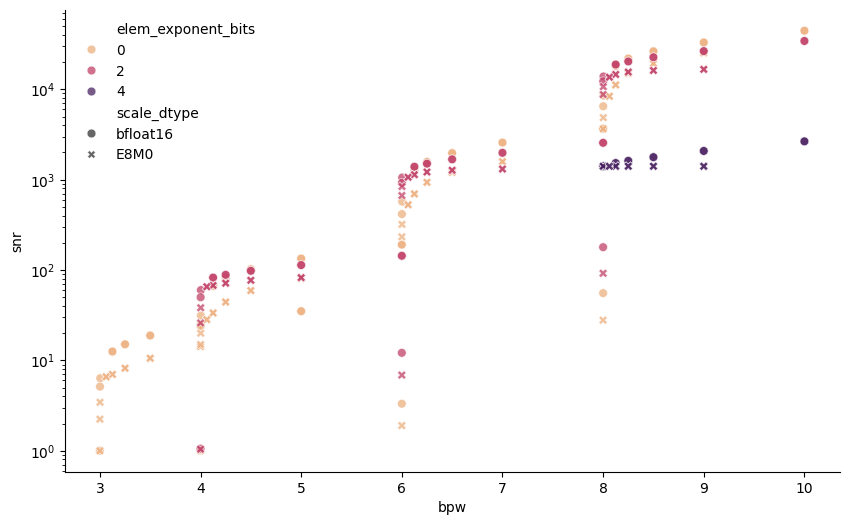

In [138]:
def flat_info(d: dict[str, Any]) -> dict[str, Any]:
    d = d.copy()
    f = d.pop("f")
    assert f["_type"] == "linear"
    assert f["scale_combiner"] is None
    d.update({f"elem_{k}": v for k, v in f["element_format"].items()})
    d.update({f"scale_{k}": v for k, v in f["scale_format"].items()})
    group, = f["group_shapes"]
    d.update(group0=group[0])
    d.update(group1=group[1])
    d.setdefault("elem_exponent_bits", 0)
    d.setdefault("elem_mantissa_bits", d.get("elem_bits_"))
    d["scale_dtype"] = "bfloat16" if d.get("scale_dtype") else "E8M0"
    del d["scale__type"]
    return d

df = pd.DataFrame.from_records([flat_info(r) for r in results["q"]])
df["bpw"] = df.bits / math.prod(results["shape"])
display(df.head())
_, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df, y="snr", x="bpw", hue="elem_exponent_bits", style="scale_dtype", palette="flare", s=40, alpha=.75, ax=ax)
ax.set_yscale("log")

## Should group-quant scale have a mantissa?

Investigation plan:
 1. SNR of Gaussians
 2. SNR of MLlama weights
 3. SNR of MLlama matmul
 4. Entropy metrics for MLlama
 5. Downstream tasks for MLlama

In [112]:
def evaluate(e_exponent: int, e_mantissa: int, s_exponent: int, s_mantissa: int, group_size: int,
             data_std: float, seed: int = 100) -> dict[str, Any]:
    torch.manual_seed(seed)
    x = data_std * torch.randn(2**20)
    fmt = Q.LinearScalingFormat(
        element_format=Q.FPFormat(e_exponent, e_mantissa, "nearest") if e_exponent >= 1 else Q.IntFormat(1 + e_mantissa),
        group_shapes=[(group_size,)],
        scale_format=Q.FPFormat_NoSign(s_exponent, s_mantissa, "to_inf"),
        scale_combiner=None,
    )
    return dict(
        bpw=fmt.count_bits(x.shape) / math.prod(x.shape),
        snr=snr(x, fmt.quantise(x)).item(),
    )

df = pd.DataFrame.from_dict(
    dict(**args, **evaluate(**args))
    for data_std in map(float, 2**torch.linspace(0, 2, 17))
    for s_mantissa in range(9)
    for e_exponent, e_mantissa in [(0, 3), (2, 1), (2, 3)]
    for group_size in [8, 16, 32, 64, 128]
    for args in [dict(
        e_exponent=e_exponent, e_mantissa=e_mantissa,
        s_exponent=8, s_mantissa=s_mantissa,
        group_size=group_size,
        data_std=data_std,
    )]
)
df["e_fmt"] = df.apply(lambda d: f"E{d.e_exponent:.0f}M{d.e_mantissa:.0f}", axis=1)
display(df.head())

,e_exponent,e_mantissa,s_exponent,s_mantissa,group_size,data_std,bpw,snr,e_fmt
0,0,3,8,0,8,1.0,5.0000,76.888985,E0M3
1,0,3,8,0,16,1.0,4.5000,57.967323,E0M3
2,0,3,8,0,32,1.0,4.2500,48.330963,E0M3
3,0,3,8,0,64,1.0,4.1250,44.285614,E0M3
4,0,3,8,0,128,1.0,4.0625,40.925785,E0M3


In [106]:
def evaluate_aomx(e_mantissa: int, data_std: float, seed: int = 100) -> dict[str, Any]:
    torch.manual_seed(seed)
    x = data_std * torch.randn(2**20)
    e_fmt = {1: "fp4_e2m1", 3: "fp6_e2m3"}[e_mantissa]
    scale, data = torchao_mx.to_mx(x, e_fmt, 32)
    q = torchao_mx.to_dtype(data, scale, e_fmt, 32, torch.float32)
    return dict(
        e_exponent=2, e_mantissa=e_mantissa,
        s_exponent=8, s_mantissa=0,
        group_size=32,
        bpw=4.25,
        data_std=data_std,
        snr=snr(x, q).item(),
    )

df_mx = pd.DataFrame.from_dict(
    evaluate_aomx(e_mantissa=e_mantissa, data_std=data_std)
    for e_mantissa in [1, 3]
    for data_std in map(float, 2**torch.linspace(0, 2, 17))
)
display(df_mx.head())

,e_exponent,e_mantissa,s_exponent,s_mantissa,group_size,bpw,data_std,snr
0,2,1,8,0,32,4.25,1.000000,75.514793
1,2,1,8,0,32,4.25,1.090508,77.615273
2,2,1,8,0,32,4.25,1.189207,77.860748
3,2,1,8,0,32,4.25,1.296840,76.368462
4,2,1,8,0,32,4.25,1.414214,74.389900


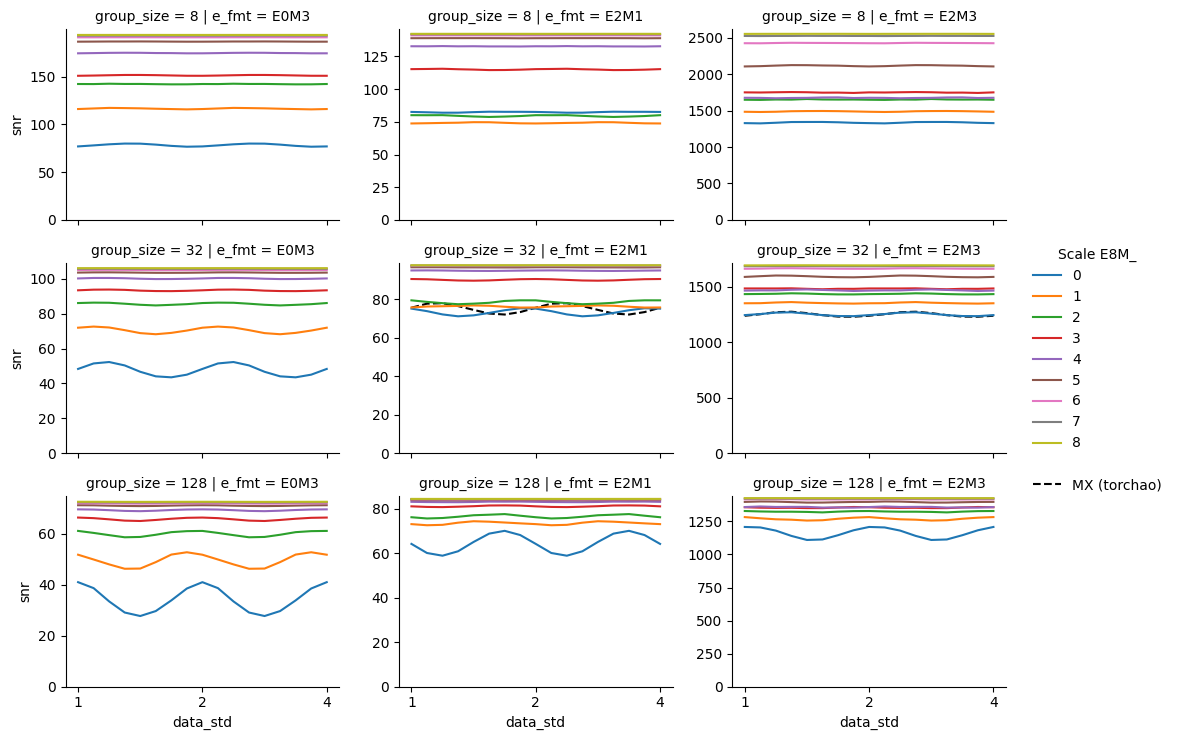

In [116]:
g = sns.relplot(data=df.assign(s_mantissa=df.s_mantissa.apply(str)), y="snr", x="data_std", hue="s_mantissa",
                row="group_size", row_order=[8, 32, 128], col="e_fmt", kind="line",
                height=2.5, aspect=1.25, facet_kws=dict(sharey=False))
for (group_size, e_fmt), ax in g.axes_dict.items():
    if group_size==32 and e_fmt=="E2M1":
        df_mx[df_mx.e_mantissa==1].plot(y="snr", x="data_std", color="k", ls="--", ax=ax, legend=False, zorder=0)
    if group_size==32 and e_fmt=="E2M3":
        df_mx[df_mx.e_mantissa==3].plot(y="snr", x="data_std", color="k", ls="--", ax=ax, legend=False, zorder=0)
    ax.set_ylim((0, ax.get_ylim()[1]))
    ax.set_xscale("log", base=2)
    ax.xaxis.set_major_formatter("{x:.0f}")
handles = list(g.legend.legend_handles)
labels = [t.get_text() for t in g.legend.texts]
handles.append(matplotlib.patches.Patch(alpha=0)), labels.append("")
handles.append(matplotlib.lines.Line2D([], [], color="k", ls="--")), labels.append("MX (torchao)")
g.legend.remove()
g.figure.legend(handles, labels, title="Scale E8M_", loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()

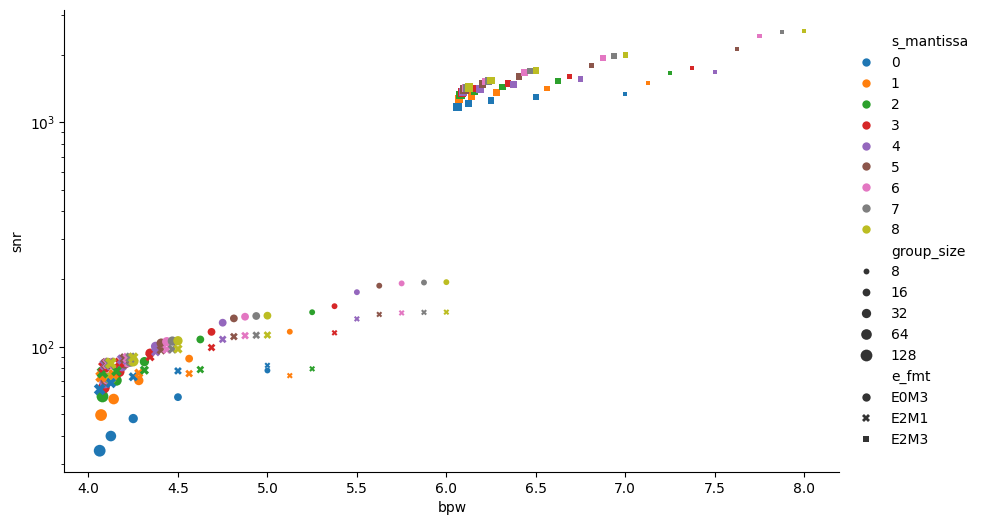

In [135]:
dfa = df.groupby(["e_fmt", "e_exponent", "e_mantissa", "s_exponent", "s_mantissa", "group_size"]).mean().reset_index()
_, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=dfa.assign(s_mantissa=dfa.s_mantissa.apply(str)), y="snr", x="bpw", hue="s_mantissa", style="e_fmt",
                size="group_size", size_norm=matplotlib.colors.LogNorm(), linewidth=0, ax=ax)
ax.set_yscale("log")
ax.legend(bbox_to_anchor=(1, .5), loc="center left");